from google.colab import drive
drive.mount("/content/MyDrive")

##Librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import hashlib
import os
import psutil
from tqdm.notebook import tqdm  # Import tqdm only once
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn.functional as F
import torch.optim as optim
from transformers import RobertaTokenizer, AutoTokenizer, AutoConfig, AutoModel
from transformers import get_linear_schedule_with_warmup
from collections import defaultdict
import time
import joblib
from copy import deepcopy
from pytorch_tabular import TabularModel
from pytorch_tabular.models.tab_transformer.config import TabTransformerConfig
from pytorch_tabular.config import DataConfig, TrainerConfig, OptimizerConfig
from torch.serialization import add_safe_globals
from omegaconf.dictconfig import DictConfig
from omegaconf.base import ContainerMetadata
from pytorch_tabular.models.tab_transformer.config import TabTransformerConfig

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"

add_safe_globals([DictConfig])
add_safe_globals([ContainerMetadata])

In [2]:
keep_frac = 0.02

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [4]:
def memory_check():
  return round(psutil.virtual_memory().used/1024**3,3)

os.chdir('/content/MyDrive/MyDrive/Colab Notebooks/securityBERT')

In [5]:
label_col = "Label"  # or the actual name of your attack type column
encoded_data_file_name = './saved_data/encoded_baseline_data_CICIDS2017'
raw_data_file_name = './saved_data/raw_baseline_data_CICIDS2017'

if (keep_frac > 0) and (keep_frac < 1.0):
    encoded_data_file_name += f'_{keep_frac}samples'
    raw_data_file_name += f'_{keep_frac}samples'

##Load saved data

In [6]:
data = pd.read_pickle(f'{encoded_data_file_name}.pck')
data_raw = pd.read_pickle(f'{raw_data_file_name}.pck')

In [7]:
data.sample(5)

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,Label
230912,8692ff1d7ae966603ddad2c0b4d46c4d6993a2a4,cb5288c48d95979fc961d8b118db503dad409463,b76ebb5ecac2a8783cb366a71ddbf0c3348af264,5b1efa21d1ae9946682dfa61543c8a3ecc22fa4e,e8b2545b331cd459e7197dc9f42083c947e3389a,bfe1697c140df62df6a70f39a44ae912f9027d81,aafe49df0d5ff27f7ec92c98c83b717f39e217f5,f61e665dffe144f8b99cc8353d9ce4ffacba8a60,a6169ff2da8d5af53ec86879747babc2ddf3529c,7c27c5941f64a73b34bb632c2710eff0af1b1e28,...,1208b66017e90e1e9b05e78120efa565f0d882a7,fcb705becc55156861ac3f80051d56c5f7208c5c,b0c157e30e0128da633b4d99ab71dc60fef4c0e6,2ebdd7e6b0fccd7421215ff4f811c893c5c58f8a,5a73d5d2d16cbe00a07e4a097a657f70ddc4128f,1da3fe787dc17a1e2d4beac055a2aa269335a700,44c265a4ccefc79f052ace707fbce9f44270dc3c,9e4af67d5e227f640a6eb3903077122cb3755d69,e0eb17c8f49cfe498eae7e4f71e750332ac98ad3,DDoS-LOIC-HTTP
786448,30421797dda6809d88cbafa2e6700aafdf82d3af,bae4ab0b2d2af4b5362a6596d5112e8772fa550d,fffd3132a06b95bdc7920d433d08b1f85700d394,419ade448c1980bd6b281ed3fd6c1046afc9a30b,848a8679d2049e9eca3dd138842bbbfa3f57e2bf,cee6f866c4117e9db591e83d544580de97ce2624,fd9e8d242712c5dd217cc5ad2067a2156ea5a8e7,410c662b5cce3d3c98374b5fb0d879cb1cc630f1,ed6038a144537917e0f1ac8d9bc9ddd1e9d1b999,ea8445709e306fff198fadfa27fe17340b82b227,...,1208b66017e90e1e9b05e78120efa565f0d882a7,d61aedf0a1a49b0eec43424f7c2fd7d106f631fc,bc87de30aac41b3009b1edb2c8747927f68a5b12,90870713eaaebfc742807f5a4a6f035296c1ffca,7c352e349f9b1b66834d3800c1142eac1d74f90e,2611bb60d1d5f773341b591c9dca1149778af897,9ce098937dab1eefdba7c5a90585f5162cd8b99b,b4b67656f28842b0db135706713f88d1e25d8202,61189a2e4d6cce090f11b8c481beaca462115d43,DDoS-Syn
2845,fe47d0b75876b331102a6b6a90a278c401531bf6,cb5288c48d95979fc961d8b118db503dad409463,fffd3132a06b95bdc7920d433d08b1f85700d394,a9c9e70c28ecfdaea1c49e4d4db146f473ebbfc8,848a8679d2049e9eca3dd138842bbbfa3f57e2bf,8058d6f2dfe881fca9bbd629de1cd328edf02fe0,7d1093b1337cdea0890b5cd7ddb816d2db1194ec,3c4826041359f19afa6f1a414a2987977288163a,ed6038a144537917e0f1ac8d9bc9ddd1e9d1b999,ea8445709e306fff198fadfa27fe17340b82b227,...,1208b66017e90e1e9b05e78120efa565f0d882a7,fcb705becc55156861ac3f80051d56c5f7208c5c,b0c157e30e0128da633b4d99ab71dc60fef4c0e6,2ebdd7e6b0fccd7421215ff4f811c893c5c58f8a,5a73d5d2d16cbe00a07e4a097a657f70ddc4128f,1da3fe787dc17a1e2d4beac055a2aa269335a700,44c265a4ccefc79f052ace707fbce9f44270dc3c,9e4af67d5e227f640a6eb3903077122cb3755d69,e0eb17c8f49cfe498eae7e4f71e750332ac98ad3,Benign
149094,ab309dc008a099a1452cfac56977b75f71ceac31,acbd2017d7d6f7020bd760c3e4f8113808b9a358,b28cd32bd566c8de4d128b9067258d86a934f314,0e1276b600e8eb8dd1e9ce88d08cc9fd994052c3,027c6b37d29e7383e9973c57f1c3cab85bff61c7,cee6f866c4117e9db591e83d544580de97ce2624,fd9e8d242712c5dd217cc5ad2067a2156ea5a8e7,410c662b5cce3d3c98374b5fb0d879cb1cc630f1,3efe0b73b21328277a7d1cc5e96a3a250c2cd317,f9043dc748b10c78172f32b3b116b6125a8eff88,...,1208b66017e90e1e9b05e78120efa565f0d882a7,fcb705becc55156861ac3f80051d56c5f7208c5c,b0c157e30e0128da633b4d99ab71dc60fef4c0e6,2ebdd7e6b0fccd7421215ff4f811c893c5c58f8a,5a73d5d2d16cbe00a07e4a097a657f70ddc4128f,1da3fe787dc17a1e2d4beac055a2aa269335a700,44c265a4ccefc79f052ace707fbce9f44270dc3c,9e4af67d5e227f640a6eb3903077122cb3755d69,e0eb17c8f49cfe498eae7e4f71e750332ac98ad3,Benign
746357,12cdfaec64e03e53bfa66b86570b6d5327e9b3d2,68ae222efa2908c04ffccaac027131ff133fc24c,fffd3132a06b95bdc7920d433d08b1f85700d394,adca63067db6c53ee39fbfbe5a783a62a0723b13,848a8679d2049e9eca3dd138842bbbfa3f57e2bf,cee6f866c4117e9db591e83d544580de97ce2624,fd9e8d242712c5dd217cc5ad2067a2156ea5a8e7,410c662b5cce3d3c98374b5fb0d879cb1cc630f1,ed6038a144537917e0f1ac8d9bc9ddd1e9d1b999,ea8445709e306fff198fadfa27fe17340b82b227,...,1208b66017e90e1e9b05e78120efa565f0d882a7,4c643b496e801b1e6400b1e57fcca128e6623f07,4d2372e37076616a31602f5bd07b46914d405852,5dda06137ccddb0c5d1076d5f56266b42e683e07,7c352e349f9b1b66834d3800c1142eac1d74f90e,d44b48842c6d62652db02f3bec2d2981e7d13e6f,6a172ad55d2792ead3bef5baf6f2f1c0151f7af3,21fa36b0a32c48348b006078a866e9d326a661

In [8]:
le = LabelEncoder()
le_raw = LabelEncoder()
data['target'] = le.fit_transform(data[label_col])
data_raw['target'] = le_raw.fit_transform(data_raw[label_col])

In [9]:
data.sample(3)

,0,1,2,3,4,5,6,7,8,9,...,49,50,51,52,53,54,55,56,Label,target
690078,1562fbddcdb1f565c1db281e0c7206da4af8c205,6e1ad5ebac4489fc5c3b6995e6496b6631a0a9ee,e84800abc864cadbd7474ead26ff61d6244106e6,9d5db298123f5e958a1f5c5c421f714d5eca3308,26a163b4bc52d01f230eea16f8a319edb94a9da6,a8e8a64be80d9ed1d6d322763e96e29d8ecf6465,7b111c5176c33522de3b4569beb3a7ce948129c1,de9585bc3345baebd87424bcca69114a9ab441d9,35c03bc33ac2fe6a56ec01b29b072e6fcb9684c0,b7066a54ab4f9cd1832ea63bbcdc46016e7f5a7f,...,fcb705becc55156861ac3f80051d56c5f7208c5c,b0c157e30e0128da633b4d99ab71dc60fef4c0e6,2ebdd7e6b0fccd7421215ff4f811c893c5c58f8a,5a73d5d2d16cbe00a07e4a097a657f70ddc4128f,1da3fe787dc17a1e2d4beac055a2aa269335a700,44c265a4ccefc79f052ace707fbce9f44270dc3c,9e4af67d5e227f640a6eb3903077122cb3755d69,e0eb17c8f49cfe498eae7e4f71e750332ac98ad3,Infiltration,28
65751,24d772b032ad308eb49e2e47db300d0f364e0234,6504bade6a9c27f36de0e803bb43ad869ad5d006,6792ea7c29ca9a174c1c682e48b4102770dfe546,2f9a134f2214af99d94aee65fa538747e4682226,09cd6bdb4d2ac8e0123f74e5f8ec9daf7b72088a,72fe5998209f78042813b079cf4964d8d3e52ef7,1222c281e3f23d8baab52b51d032f0a1fd06ec8a,66ac68f5933fdb6fbae6147e20fd337dff350fb3,6de4eb781475443adcc0de5925b19a4698280690,558117f7301c010f7d3176bf87002d0f5fdcf617,...,fcb705becc55156861ac3f80051d56c5f7208c5c,b0c157e30e0128da633b4d99ab71dc60fef4c0e6,2ebdd7e6b0fccd7421215ff4f811c893c5c58f8a,5a73d5d2d16cbe00a07e4a097a657f70ddc4128f,1da3fe787dc17a1e2d4beac055a2aa269335a700,44c265a4ccefc79f052ace707fbce9f44270dc3c,9e4af67d5e227f640a6eb3903077122cb3755d69,e0eb17c8f49cfe498eae7e4f71e750332ac98ad3,Benign,0
568830,4c1a3003ae4350b46b20b277e1d78077416cb968,658cf11bc33aa32be66ea55a18306e9f9771df9d,fffd3132a06b95bdc7920d433d08b1f85700d394,7b994ff53f2f17513e1299bd904e5d1ce0ff80d8,848a8679d2049e9eca3dd138842bbbfa3f57e2bf,e765065a077b9ec16bfe45e4e8c5bffe64988d1d,e71f81e454f7a31f9da8d9feedac57e38ead7299,410c662b5cce3d3c98374b5fb0d879cb1cc630f1,ed6038a144537917e0f1ac8d9bc9ddd1e9d1b999,ea8445709e306fff198fadfa27fe17340b82b227,...,fcb705becc55156861ac3f80051d56c5f7208c5c,b0c157e30e0128da633b4d99ab71dc60fef4c0e6,2ebdd7e6b0fccd7421215ff4f811c893c5c58f8a,5a73d5d2d16cbe00a07e4a097a657f70ddc4128f,1da3fe787dc17a1e2d4beac055a2aa269335a700,44c265a4ccefc79f052ace707fbce9f44270dc3c,9e4af67d5e227f640a6eb3903077122cb3755d69,e0eb17c8f49cfe498eae7e4f71e750332ac98ad3,DDoS-TFTP,16


In [10]:
data = data.drop(columns=[label_col])
data_raw = data_raw.drop(columns=[label_col])
data_int = deepcopy(data)

In [11]:
def hex_to_byte_array(hex_str):
    if not isinstance(hex_str, str):
        # Handle NaNs or non-strings gracefully
        print(f"{hex_str} not instance of str")
        return []
    # Remove 0x prefix if present
    hex_str = hex_str.strip().lower()
    if hex_str.startswith('0x'):
        hex_str = hex_str[2:]
    # Remove any whitespace
    hex_str = hex_str.replace(' ', '')
    # If empty after cleaning, return empty list
    if len(hex_str) == 0:
        print("length is 0")
        return []
    # If odd length, pad with leading zero
    if len(hex_str) % 2 != 0:
        hex_str = '0' + hex_str
    # Validate characters are hex digits
    if any(c not in '0123456789abcdef' for c in hex_str):
        # Handle invalid characters by returning empty or raise custom error
        print(f"{hex_str} not all in 0123456789abcdef")
        return []
    # Convert hex string to byte list
    byte_array = bytes.fromhex(hex_str)
    return list(byte_array)

feature_cols = data_int.drop(columns='target').columns
byte_matrix_df = data_int[feature_cols].applymap(hex_to_byte_array)
X = byte_matrix_df.apply(lambda row: sum(row, []), axis=1).to_list()
X = np.array(X)
y = data_int['target'].values

In [12]:
sorted(data['target'].unique())

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32]

In [13]:
# data.to_pickle('./encoded_data.pickle')

In [14]:
memory_check()

21.882

In [15]:
row_strings = [' '.join(map(str, row)) for row in X]

In [16]:
with open(f'{encoded_data_file_name}.txt',"w") as f:
  for value in tqdm(row_strings):
    f.write(str(value)+'\n')

  0%|          | 0/894198 [00:00<?, ?it/s]

##Data splitting

In [17]:
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

In [18]:
train_set, test_set = train_test_split(data, test_size=test_ratio,stratify=data.iloc[:,-1], random_state=42)
train_set, val_set = train_test_split(train_set, test_size=val_ratio/(val_ratio+train_ratio),stratify=train_set.iloc[:,-1], random_state=42)
train_set_raw, test_set_raw = train_test_split(data_raw, test_size=test_ratio,stratify=data_raw.iloc[:,-1], random_state=42)
train_set_raw, val_set_raw = train_test_split(train_set_raw, test_size=val_ratio/(val_ratio+train_ratio),stratify=train_set_raw.iloc[:,-1], random_state=42)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=test_ratio,
    stratify=y,
    random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_ratio / (train_ratio + val_ratio),
    stratify=y_temp,
    random_state=42
)

In [19]:
train_set.shape,val_set.shape,test_set.shape

((625938, 58), (134130, 58), (134130, 58))

In [20]:
TARGET_LIST = le.classes_
TARGET_LIST

array(['Benign', 'Botnet', 'Bruteforce-FTP', 'Bruteforce-SSH', 'DDoS',
       'DDoS-DNS', 'DDoS-Ddossim', 'DDoS-HOIC', 'DDoS-LDAP',
       'DDoS-LOIC-HTTP', 'DDoS-MSSQL', 'DDoS-NTP', 'DDoS-NetBIOS',
       'DDoS-SNMP', 'DDoS-Slowloris', 'DDoS-Syn', 'DDoS-TFTP', 'DDoS-UDP',
       'DDoS-UDPLag', 'DoS-Goldeneye', 'DoS-Heartbleed', 'DoS-Hulk',
       'DoS-Rudy', 'DoS-Slowbody', 'DoS-Slowheaders', 'DoS-Slowhttptest',
       'DoS-Slowloris', 'DoS-Slowread', 'Infiltration', 'Portscan',
       'Webattack-SQLi', 'Webattack-XSS', 'Webattack-bruteforce'],
      dtype=object)

# Model Configurations

##Training and Evaluation

In [21]:
from collections import defaultdict
from pytorch_lightning.callbacks import Callback

class MetricsRecorder(Callback):
    def __init__(self):
        super().__init__()
        self.metrics = defaultdict(list)
        self._last_val_epoch = -1  # <-- initialize here

    def on_train_epoch_end(self, trainer, pl_module):
        logs = trainer.callback_metrics
        # training metrics logged usually have "train_" prefix
        train_loss = logs.get("train_loss")
        train_acc = logs.get("train_accuracy") or logs.get("train_acc")
        if train_loss is not None:
            self.metrics["train_loss"].append(train_loss.item() if hasattr(train_loss, "item") else train_loss)
        if train_acc is not None:
            self.metrics["train_acc"].append(train_acc.item() if hasattr(train_acc, "item") else train_acc)

    def on_validation_epoch_end(self, trainer, pl_module):
        # Append val metrics only once per epoch
        current_epoch = trainer.current_epoch
        if current_epoch == self._last_val_epoch:
            return  # already recorded for this epoch

        logs = trainer.callback_metrics
        val_loss = logs.get("val_loss") or logs.get("valid_loss") or logs.get("valid_loss_0")
        val_acc = logs.get("val_accuracy") or logs.get("valid_accuracy")

        if val_loss is not None:
            self.metrics["val_loss"].append(val_loss.item() if hasattr(val_loss, "item") else val_loss)
        if val_acc is not None:
            self.metrics["val_acc"].append(val_acc.item() if hasattr(val_acc, "item") else val_acc)

        self._last_val_epoch = current_epoch

In [32]:
def train_tabtransformer_pytorch(X_train, y_train, X_val, y_val, name="baseline_tabTransformer_cicids2017_0.02samples", model_directory="baseline_model/", epochs=3, batch_size=64, hidden_dim=64, lr=0.001):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 🔹 Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
    X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)
    X_train_scaled = X_train_scaled.astype(np.float32)
    X_val_scaled = X_val_scaled.astype(np.float32)

    # 🔹 Convert to tensors
    train_df = X_train_scaled
    val_df = X_val_scaled
    train_df["target"] = y_train
    val_df["target"] = y_val

    # 🔹 Create DataLoaders
    train_loader = DataLoader(train_df, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_df, batch_size=batch_size, shuffle=False)

    input_dim = X_train.shape[1]
    num_classes = len(np.unique(y_train))

    # 🔹 Configurations
    data_config = DataConfig(
        target=["target"],  # specify your target column name
        continuous_cols=X_train.columns.tolist(),
        categorical_cols=[],  # specify if you have any categorical columns
        num_workers=4,
    )

    model_config = TabTransformerConfig(
        task="classification",
        learning_rate=lr,
        metrics=["accuracy"],
        input_embed_dim=32,  # embedding dimension for inputs
        num_heads=4,         # number of attention heads
        num_attn_blocks=2,   # number of attention layers
        attn_dropout=0.1,
        add_norm_dropout=0.1,
        ff_dropout=0.1,
        ff_hidden_multiplier=2,
    )

    trainer_config = TrainerConfig(
        load_best=False,
        auto_lr_find=False,
        batch_size=batch_size,
        max_epochs=epochs,
        accelerator="gpu" if torch.cuda.is_available() else "cpu",
        devices=1 if torch.cuda.is_available() else None,
        check_val_every_n_epoch=1,
    )

    optimizer_config = OptimizerConfig(
        optimizer="AdamW",  # Optimizer
        optimizer_params={ "weight_decay": 0.01 }  # Regularization
    )

    # 🔹 Create the TabularModel
    tabular_model = TabularModel(
        data_config=data_config,
        model_config=model_config,
        trainer_config=trainer_config,
        optimizer_config=optimizer_config,
    )

    # 🔹 Metrics Recorder
    metrics_recorder = MetricsRecorder()

    # 🔹 Start Training
    start_time = time.time()
    tabular_model.fit(train=train_df, validation=val_df, callbacks=[metrics_recorder])
    training_time = time.time() - start_time

    # 🔹 Return the model, training time, metrics, and scaler
    return tabular_model, training_time, metrics_recorder.metrics, scaler

In [23]:
def clean_float_str(x):
    return ('{:.10f}'.format(x)).rstrip('0').rstrip('.')  # Keeps precision up to 10 digits, then trims

In [24]:
model_directory = 'baseline_model/'
keep_frac = 0.02
num_epochs=3
model_version = f"baseline_tabTransformer_cicids2017_{keep_frac}samples"
figure_version = f"TabTransformer {clean_float_str(keep_frac * 100)}% Samples"
figure_file_name = f'baseline-tab-transformer-{keep_frac}samples'
batch_size=64

In [ ]:
X_train = pd.DataFrame(X_train)
X_val = pd.DataFrame(X_val)
tabtranformer_model, training_time, history_tabtransformer, scaler_tabtransformer = train_tabtransformer_pytorch(X_train, y_train, X_val, y_val, name='baseline_tabTransformer_cicids2017_0.02samples')
history_tabtransformer["training_time"].append(training_time)
torch.save(tabtranformer_model.model.state_dict(), f"./{model_directory}{model_version}.pth")
torch.save(history_tabtransformer,f"./{model_directory}history_{model_version}.pt")

Windows does not support num_workers > 0. Setting num_workers to 0


2025-07-19 23:28:53,290 - {pytorch_tabular.tabular_model:146} - INFO - Experiment Tracking is turned off

Seed set to 42


2025-07-19 23:28:53,350 - {pytorch_tabular.tabular_model:548} - INFO - Preparing the DataLoaders

2025-07-19 23:28:58,902 - {pytorch_tabular.tabular_datamodule:522} - INFO - Setting up the datamodule for          
classification task

...

2025-07-19 23:29:09,540 - {pytorch_tabular.tabular_model:678} - INFO - Training Started

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                   ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ _backbone        │ TabTransformerBackbone │ 47.7 K │ train │
│ 1 │ _embedding_layer │ Embedding2dLayer       │      0 │ train │
│ 2 │ _head            │ LinearHead             │ 37.7 K │ train │
│ 3 │ loss             │ CrossEntropyLoss       │      0 │ train │
└───┴──────────────────┴────────────────────────┴────────┴───────┘

Trainable params: 85.3 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 85.3 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 47                                                                                          
Modules in eval mode: 0

Output()

In [ ]:
import torch
import torch.nn.functional as F
from tqdm import tqdm

def get_predictions_tt(model, X_test, y_test, device):
    """
    Makes predictions using a trained PyTorch TabularModel (TabTransformer) model.

    Args:
        model: Trained TabularModel.
        X_test: Test features (Pandas DataFrame).
        y_test: True labels (array-like or Series).
        device: "cpu" or "cuda".

    Returns:
        predictions: Tensor of predicted class labels.
        predictions_probs: Tensor of predicted probabilities.
        real_values: Tensor of true labels.
        avg_inference_time_ms: Average inference time per sample in ms.
    """
    import time
    from tqdm import tqdm
    import torch
    import torch.nn.functional as F

    model.model.eval()

    # Ensure inputs are float32
    X_test = X_test.astype(np.float32)

    # Create a single DataFrame with features + target
    test_df = X_test.copy()
    test_df["target"] = y_test

    # Lists to store results
    predictions, predictions_probs, real_values = [], [], []
    total_time = 0.0

    for idx in tqdm(range(len(test_df)), desc="Predictions"):
        row = test_df.iloc[[idx]]  # Keep row as DataFrame
        start_time = time.perf_counter()

        pred_dict = model.predict(row, ret_logits=True)  # Returns dict with "logits", "prediction", etc.

        end_time = time.perf_counter()
        total_time += (end_time - start_time)

        logits = torch.tensor(pred_dict["logits"][0])
        probs = F.softmax(logits, dim=0)
        pred_label = torch.argmax(probs)

        predictions.append(pred_label)
        predictions_probs.append(probs)
        real_values.append(y_test[idx])

    # Convert to tensors
    predictions = torch.stack(predictions)
    predictions_probs = torch.stack(predictions_probs)
    real_values = torch.tensor(real_values)

    avg_inference_time_ms = (total_time / len(test_df)) * 1000
    print(f"Average per-sample inference time: {avg_inference_time_ms:.4f} ms")

    return predictions, predictions_probs, real_values, avg_inference_time_ms

In [ ]:
X_test = pd.DataFrame(X_test)
X_test_scaled = scaler_tabtransformer.transform(X_test)

In [ ]:
predictions,predictions_probs,real_values,inference_time = get_predictions_tt(tabtranformer_model,X_test_scaled,y_test,device)
torch.save(predictions,f"./{model_directory}y_pred_{model_version}.pt")
torch.save(predictions_probs,f"./{model_directory}y_proba_{model_version}.pt")
torch.save(real_values,f"./{model_directory}real_values_{model_version}.pt")
torch.save(inference_time,f"./{model_directory}inference_time_{model_version}.pt")

NameError: name 'securityBert' is not defined

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report

In [ ]:
s = set()

In [ ]:
for elt in predictions:
  s.add(elt.item())

In [ ]:
acutal_considered_classes = [TARGET_LIST[i] for i in s]
acutal_considered_classes

['Backdoor',
 'DDoS_HTTP',
 'DDoS_ICMP',
 'DDoS_TCP',
 'DDoS_UDP',
 'MITM',
 'Normal',
 'Password',
 'Port_Scanning',
 'Ransomware',
 'SQL_injection',
 'Uploading',
 'Vulnerability_scanner',
 'XSS']

In [ ]:
data['Attack_type'].value_counts()

Attack_type
Normal                   24301
DDoS_UDP                 14498
DDoS_ICMP                14090
Ransomware               10925
DDoS_HTTP                10561
SQL_injection            10311
Uploading                10269
DDoS_TCP                 10247
Backdoor                 10195
Vulnerability_scanner    10076
Port_Scanning            10071
XSS                      10052
Password                  9989
MITM                      1214
Fingerprinting            1001
Name: count, dtype: int64

In [ ]:
def show_confusion_matrix(confusion_matrix):

    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix, annot=True, cmap='Blues', fmt='d')
    plt.xticks(rotation=90)
    plt.title("Matrice de confusion")
    plt.ylabel('Real threats')
    plt.xlabel('Predicted threats')
    plt.savefig('./securityBert3-mod-confusion-matrix.png',dpi=780)
    plt.show()






In [ ]:
from sklearn.metrics import confusion_matrix,classification_report

In [ ]:
print(classification_report(real_values,predictions,target_names=TARGET_LIST))

                       precision    recall  f1-score   support

             Backdoor       0.70      0.80      0.75      1529
            DDoS_HTTP       0.54      0.99      0.70      1584
            DDoS_ICMP       0.92      0.98      0.95      2114
             DDoS_TCP       0.99      0.98      0.99      1537
             DDoS_UDP       0.98      0.99      0.99      2175
       Fingerprinting       0.00      0.00      0.00       150
                 MITM       1.00      0.99      1.00       182
               Normal       1.00      0.99      1.00      3645
             Password       0.98      0.12      0.21      1498
        Port_Scanning       0.91      0.91      0.91      1511
           Ransomware       0.70      0.62      0.66      1639
        SQL_injection       1.00      0.99      1.00      1547
            Uploading       0.97      1.00      0.99      1540
Vulnerability_scanner       1.00      1.00      1.00      1511
                  XSS       1.00      1.00      1.00  

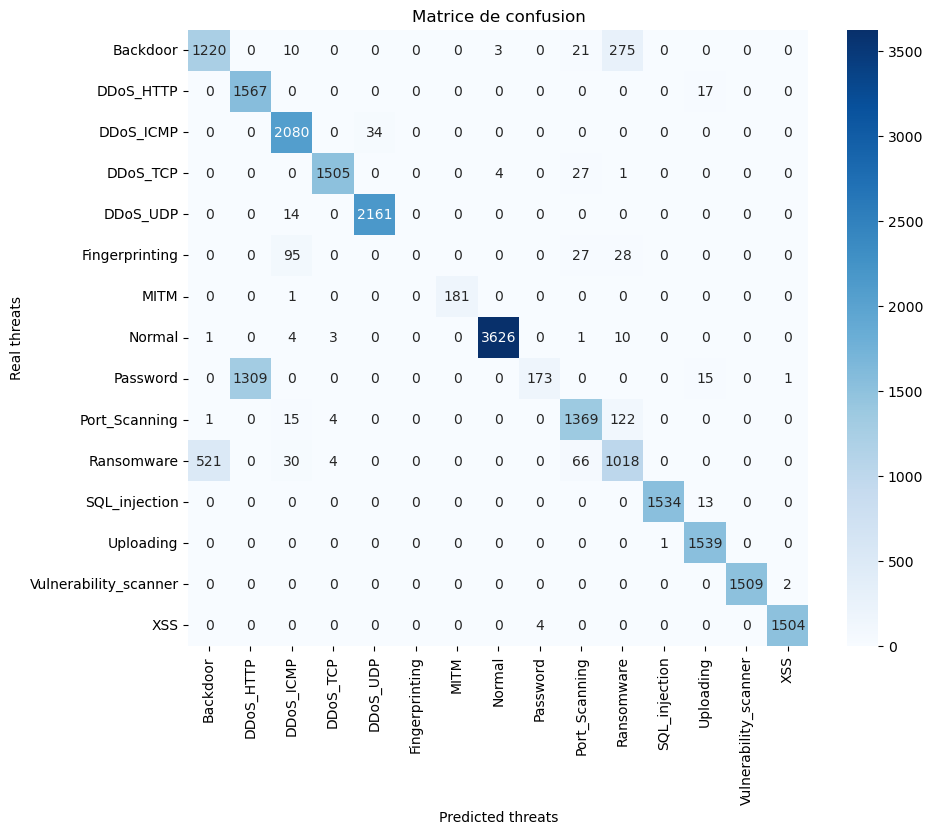

In [ ]:
cm = confusion_matrix(real_values,predictions)
df_cm = pd.DataFrame(cm,index=TARGET_LIST,columns=TARGET_LIST)
show_confusion_matrix(df_cm)

In [ ]:
y_true = real_values.cpu().numpy()
y_score = predictions.cpu().numpy()


In [ ]:
import sklearn.metrics as metrics